# BandStructureSim — Tutorial Notebook

A hands-on guide to computing photonic-crystal slab band structures with the
`BandStructureSim` class, which wraps MIT's [MPB](https://mpb.readthedocs.io/) solver.

All physical dimensions are in **µm**. Frequencies are returned in normalised
units (c/a) and can be converted to THz or Hz.

## 0 — Imports

Place `bandstructure_class.py` in the same directory as this notebook (or on your Python path).

In [11]:
from bandstructure_class import BandStructureSim
import numpy as np
import matplotlib.pyplot as plt
import tidy3d as td
C0 = td.constants.C_0

%matplotlib inline

## 1 — Creating a Simulation Object

`BandStructureSim` models a **1-D periodic dielectric slab** with air holes.

### Constructor parameters

| Parameter | Description |
|---|---|
| `Lx` | Lattice constant along x (µm). Used as the normalisation unit *a*. |
| `Ly` | Width of the nanobeam / slab in y (µm). |
| `thickness` | Slab thickness in z (µm). |
| `geometry` | Hole shape: `"circular"`, `"ellipse"`, or `"square"`. |
| `hole_params` | Hole dimensions in µm — `[diameter]` for circular, `[sx, sy]` for ellipse/square. |
| `material_index` | Refractive index of the slab material. |
| `factor_y`, `factor_z` | Supercell padding multipliers (default 5 and 10). |
| `num_bands` | Number of frequency bands to compute. |
| `resolution` | Grid points per unit cell. Higher = more accurate but slower. |

### 1.1 — Circular holes

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 96 x 70.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 5.83333, 0)
     (0, 0, 4.16667)
Cell volume = 24.3056
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.171429, -0)
     (0, -0, 0.24)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,1.16667,0.416667)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.583333,0.583333,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -2.97743..2.97743, -2.14286..2.14286)
          bounding box (-0.291667..0.291667, -0.291667..0.291667, -5e+19..5e+19)
          shift object by (0, 0, -4.16667)
          ellipsoid, center = (0,0,0)
               size (0.583333,0.583333,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          boundin

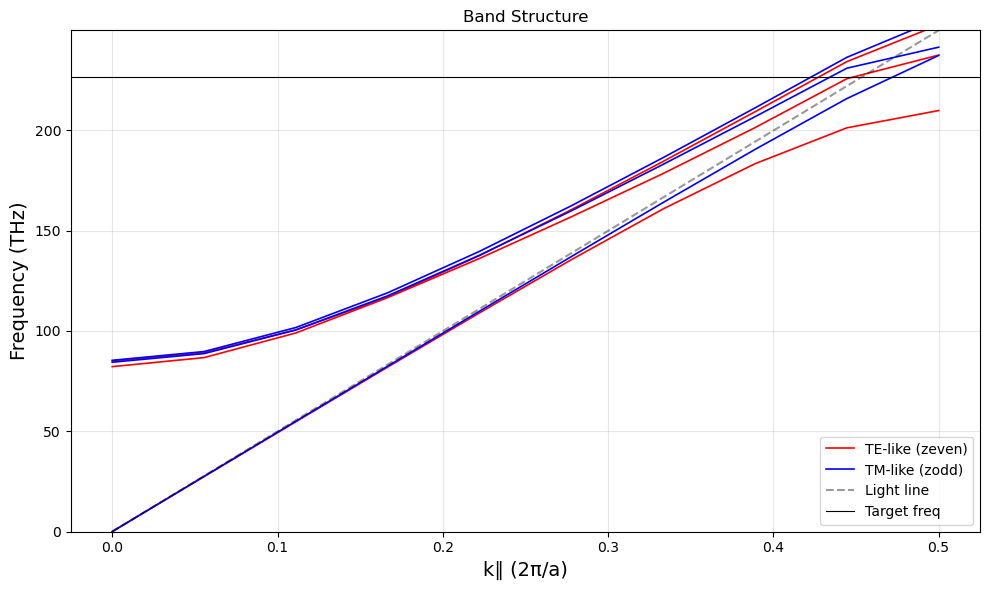

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Band Structure'}, xlabel='k∥ (2π/a)', ylabel='Frequency (THz)'>)

In [13]:
thickness = 0.25
wl0 = 1.324
freq0 = C0 / wl0


Lx = 0.6
Ly = 0.7
dx = 0.35
dy = 0.35

sim = BandStructureSim(
    Lx=Lx, Ly=Ly, thickness=thickness,
    geometry="ellipse", hole_params=[dx, dy],
    material_index=2.0, num_bands=3, resolution=16,
)
sim.run_bandstructure(k_min=0, k_max=0.5, n_k=8)
sim.plot_bands(units='THz', freq0_Hz=freq0)


In [14]:
sim = BandStructureSim(
    Lx=0.47,
    Ly=1,
    thickness=0.250,
    geometry="ellipse",
    hole_params=[0.250, 0.250],  # [size_x, size_y] in µm
    material_index=2.0,
    num_bands=4,
    resolution=16,
)

## 2 — Computing a Band Structure

Call `run_bandstructure()` to solve for both **TE-like (z-even)** and **TM-like (z-odd)** modes
along a 1-D k-path from `k_min` to `k_max` (in units of 2π/a).

In [15]:
kpts, kpar, zeven_freqs, zodd_freqs = sim.run_bandstructure(
    k_min=0.0,  # start of k-path
    k_max=0.5,  # band edge (π/a)
    n_k=8,     # number of interpolated k-points
)

Initializing eigensolver data
Computing 4 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 175 x 90.
Solving for 4 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10.6383, 0)
     (0, 0, 5.31915)
Cell volume = 56.5867
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.094, -0)
     (0, -0, 0.188)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.12766,0.531915)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.531915,0.531915,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.37994..5.37994, -2.71868..2.71868)
          bounding box (-0.265957..0.265957, -0.265957..0.265957, -5e+19..5e+19)
          shift object by (0, 0, -5.31915)
          ellipsoid, center = (0,0,0)
               size (0.531915,0.531915,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding

### Understanding the outputs

- `kpts` — shape `(n_k, 3)`: full 3-D k-vectors
- `kpar` — shape `(n_k,)`: magnitude of in-plane k
- `zeven_freqs` — shape `(n_k, num_bands)`: TE-like frequencies in c/a
- `zodd_freqs` — shape `(n_k, num_bands)`: TM-like frequencies in c/a

In [8]:
print("k-points shape:", kpts.shape)
print("kpar shape:    ", kpar.shape)
print("TE freqs shape:", zeven_freqs.shape)
print("TM freqs shape:", zodd_freqs.shape)

k-points shape: (10, 3)
kpar shape:     (10,)
TE freqs shape: (10, 4)
TM freqs shape: (10, 4)


## 3 — Unit Conversions

The class provides helpers to convert between normalised frequency (c/a), THz, and Hz.

In [16]:
# Normalised → THz
freq_THz = sim.freq_norm_to_THz(zeven_freqs)
print("TE band 0 at k=π/a:", freq_THz[-1, 0], "THz")

# Normalised → Hz
freq_Hz = sim.freq_norm_to_Hz(zeven_freqs)

# Hz → Normalised (round-trip)
freq_norm = sim.freq_Hz_to_norm(freq_Hz)
print("Round-trip error:", np.max(np.abs(freq_norm - zeven_freqs)))

TE band 0 at k=π/a: 228.75728307958224 THz
Round-trip error: 2.7755575615628914e-17


## 4 — Plotting the Band Structure

### 4.1 — Normalised units

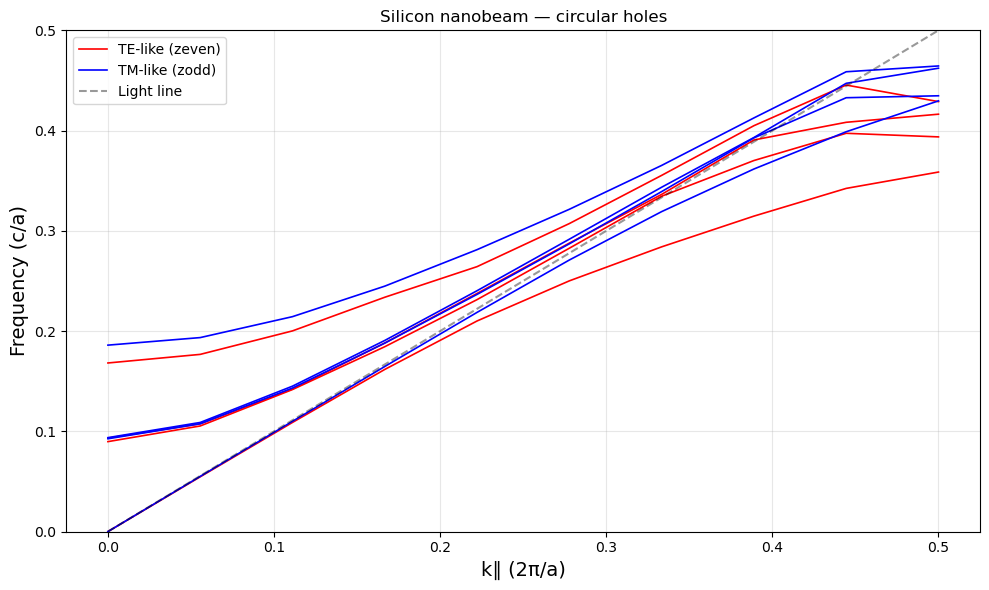

In [17]:
fig, ax = sim.plot_bands(
    units='norm',
    title='Silicon nanobeam — circular holes',
)

### 4.2 — THz units with a target frequency

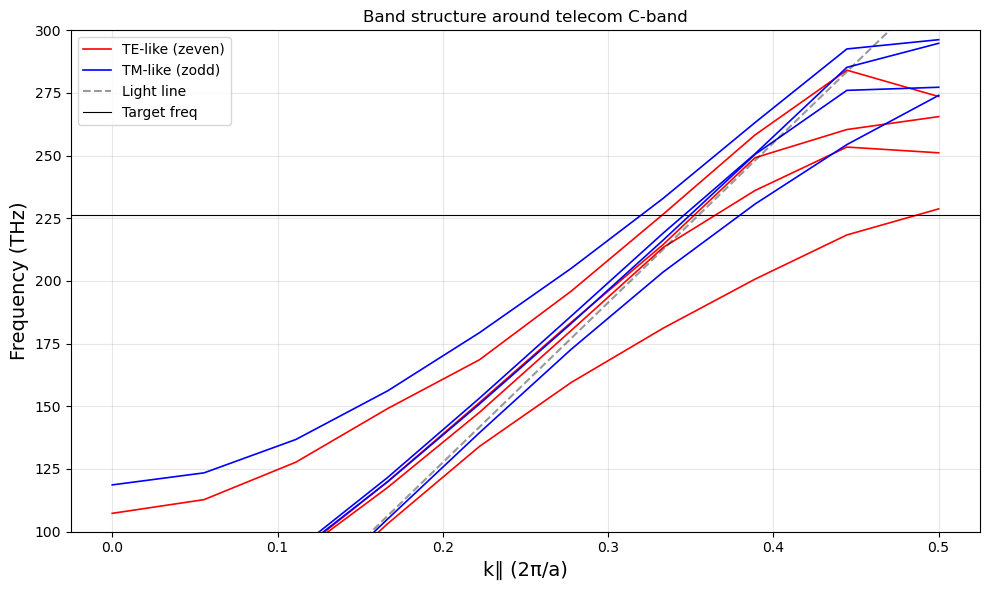

In [18]:
wavelength = 1.324
f_target = C0 / wavelength

fig, ax = sim.plot_bands(
    units='THz',
    freq0_Hz=f_target,
    ylim=(100, 300),
    title='Band structure around telecom C-band',
)

## 5 — Visualising the Dielectric Profile

After running any simulation you can inspect the permittivity cross-section at z = 0.
The `periods` argument controls how many unit cells are shown.

epsilon: 1-4, mean 1.05384, harm. mean 1.01406, 1.9% > 1, 1.79455% "fill"
real part range: 1 .. 4


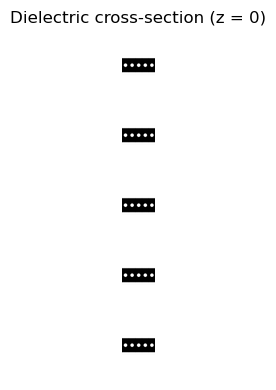

In [19]:
fig, ax = sim.plot_epsilon(periods=5)

## 6 — Single k-point Calculation

Use `run_at_k()` when you only need the frequencies at one wavevector.
This is much faster than a full band structure and is handy inside optimisation loops.

In [20]:
kpts, kpar, zeven, zodd = sim.run_at_k(kx=0.5)

print("TE-like frequencies at k = π/a:", zeven)
print("TM-like frequencies at k = π/a:", zodd)

Initializing eigensolver data
Computing 4 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 175 x 90.
Solving for 4 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10.6383, 0)
     (0, 0, 5.31915)
Cell volume = 56.5867
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.094, -0)
     (0, -0, 0.188)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.12766,0.531915)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.531915,0.531915,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.37994..5.37994, -2.71868..2.71868)
          bounding box (-0.265957..0.265957, -0.265957..0.265957, -5e+19..5e+19)
          shift object by (0, 0, -5.31915)
          ellipsoid, center = (0,0,0)
               size (0.531915,0.531915,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding

## 7 — Parameter Sweeps (1-D)

Investigate how band frequencies change as you vary a single geometric parameter.

### Available `param_name` values

| `param_name` | What it sweeps |
|---|---|
| `'p1'` | First hole parameter (diameter for circular, x-size for ellipse/square) |
| `'p2'` | Second hole parameter (y-size for ellipse/square) |
| `'Lx'` | Lattice constant |
| `'Ly'` | Slab width |
| `'thickness'` | Slab thickness |

### 7.1 — Sweep the hole diameter

In [21]:
diameters = np.linspace(0.15, 0.3, 10)  # µm

sweep = sim.run_sweep(
    param_name='p1',
    param_values_um=diameters,
    kx=0.5,  # evaluate at the band edge
)

Initializing eigensolver data
Computing 4 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 175 x 90.
Solving for 4 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 10.6383, 0)
     (0, 0, 5.31915)
Cell volume = 56.5867
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.094, -0)
     (0, -0, 0.188)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.12766,0.531915)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.319149,0.531915,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -5.37994..5.37994, -2.71868..2.71868)
          bounding box (-0.159574..0.159574, -0.265957..0.265957, -5e+19..5e+19)
          shift object by (0, 0, -5.31915)
          ellipsoid, center = (0,0,0)
               size (0.319149,0.531915,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding

### 7.2 — Plot the sweep

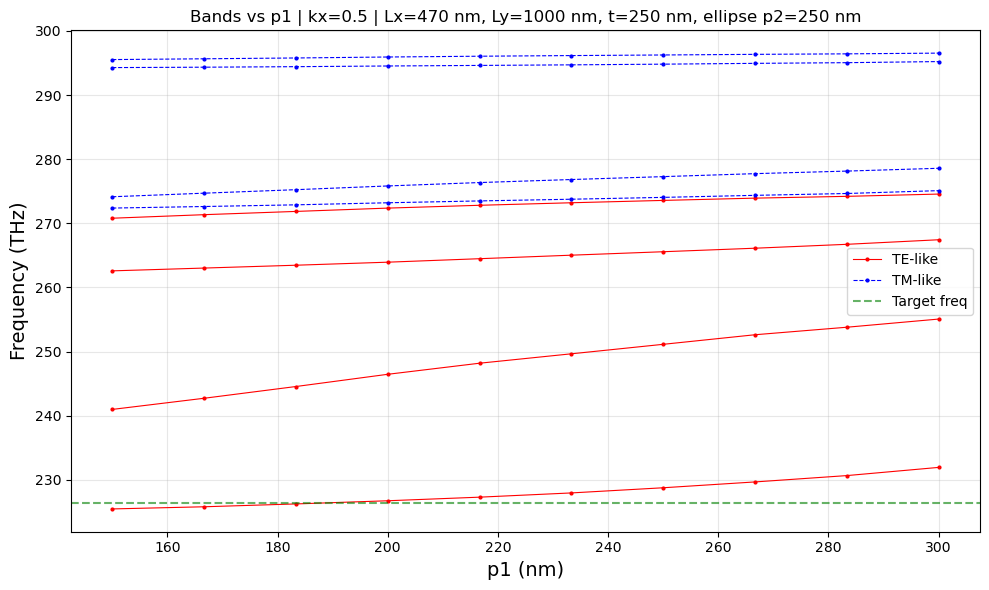

In [22]:
fig, ax = sim.plot_sweep(
    units='THz',
    freq0_Hz=f_target,  # optional target frequency line
)

### 7.3 — Access raw sweep data

In [23]:
sd = sim.sweep_data

print("Keys:", list(sd.keys()))
print("Shape of TE freqs:", sd['zeven_freqs'].shape)  # (n_param_values, num_bands)
print("Band 0 TE-like freqs (c/a):", sd['zeven_freqs'][:, 0])

Keys: ['param_name', 'param_values_um', 'kx', 'zeven_freqs', 'zodd_freqs', 'Lx_per_point']
Shape of TE freqs: (10, 4)
Band 0 TE-like freqs (c/a): [0.35345811 0.35398559 0.3546815  0.35545681 0.35633532 0.35737128
 0.35863452 0.36006045 0.36161147 0.36361517]


## 8 — Multi-Parameter Sweeps (N-D)

Sweep over a grid of two or more parameters simultaneously.

### 8.1 — Run a 2-D sweep

In [24]:
multisweep = sim.run_multisweep(
    param_ranges={
        'Lx': np.linspace(0.40, 0.60, 6),  # lattice constant (µm)
        'p1': np.linspace(0.150, 0.30, 6),  # hole diameter (µm)
    },
    kx=0.5,
)

Initializing eigensolver data
Computing 4 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 16 x 200 x 100.
Solving for 4 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 12.5, 0)
     (0, 0, 6.25)
Cell volume = 78.125
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.08, -0)
     (0, -0, 0.16)
Geometric objects:
     block, center = (0,0,0)
          size (1e+20,2.5,0.625)
          axes (1,0,0), (0,1,0), (0,0,1)
     ellipsoid, center = (0,0,0)
          size (0.375,0.625,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
Geometry object bounding box tree:
     box (-0.5625..0.5625, -6.3125..6.3125, -3.1875..3.1875)
          bounding box (-0.1875..0.1875, -0.3125..0.3125, -5e+19..5e+19)
          shift object by (0, 0, -6.25)
          ellipsoid, center = (0,0,0)
               size (0.375,0.625,1e+20)
               axes (1,0,0), (0,1,0), (0,0,1)
          bounding box (-0.1875..0.1875, -0.3125..0.3125, -5

### 8.2 — Plot a 2-D colour map

The colour map uses a diverging RdBu palette centred on zero, so **white = matching the target frequency**.

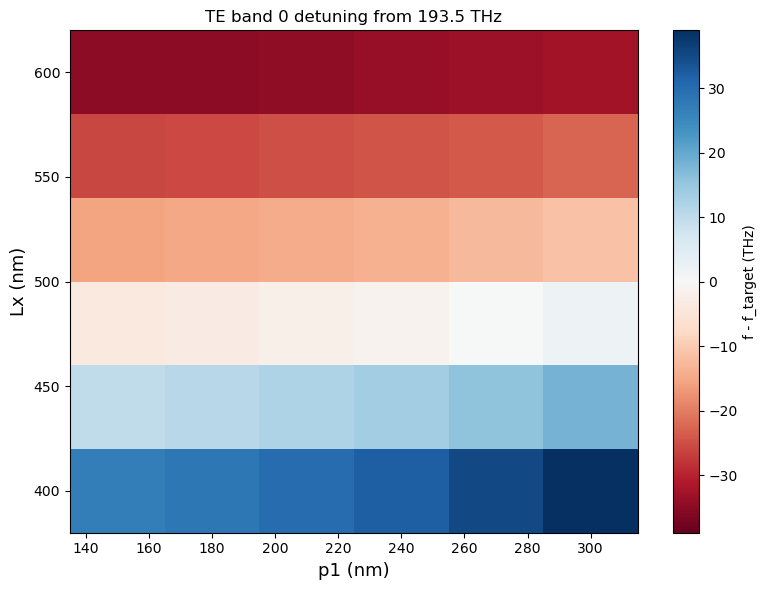

In [25]:
fig, ax = sim.plot_multisweep(
    band_idx=0,
    polarization='zeven',  # 'zeven' (TE-like) or 'zodd' (TM-like)
    units='THz',
    freq0_Hz=f_target,     # subtracts target → shows detuning
    title='TE band 0 detuning from 193.5 THz',
)

### 8.3 — Access raw multisweep data

In [26]:
md_data = sim.multisweep_data

print("Parameter names:", md_data['param_names'])
print("Grid shape:     ", md_data['grid_shape'])
print("TE freqs shape: ", md_data['zeven_freqs'].shape)  # (*grid_shape, 1, num_bands)

# Access individual parameter arrays
lx_vals = md_data['param_grids']['Lx']
p1_vals = md_data['param_grids']['p1']
print("Lx values (µm):", lx_vals)
print("p1 values (µm):", p1_vals)

Parameter names: ['Lx', 'p1']
Grid shape:      (6, 6)
TE freqs shape:  (6, 6, 1, 4)
Lx values (µm): [0.4  0.44 0.48 0.52 0.56 0.6 ]
p1 values (µm): [0.15 0.18 0.21 0.24 0.27 0.3 ]


## 9 — Saving and Loading Results

Results are saved as a `.npz` file (arrays) plus a `_meta.json` file (parameters and gaps).

### 9.1 — Save

In [ ]:
sim.save(directory='results', name='silicon_nanobeam_circular')

# Creates:
#   results/silicon_nanobeam_circular.npz
#   results/silicon_nanobeam_circular_meta.json

### 9.2 — Load into a new object

In [ ]:
sim2 = BandStructureSim(
    Lx=0.350, Ly=0.500, thickness=0.220,
    geometry="circular", hole_params=[0.200],
    material_index=3.48, num_bands=6, resolution=32,
)

sim2.load(directory='results', name='silicon_nanobeam_circular')

# Plot without re-running the simulation
fig, ax = sim2.plot_bands(units='THz')

## 11 — Tips and Best Practices

**Resolution** — Start with `resolution=16` for quick exploration. Increase to 32 or 64
for publication-quality results. Computation time scales roughly as resolution³.

**Supercell padding** — The defaults `factor_y=5` and `factor_z=10` work well for most
nanobeam geometries. If you see spurious flat bands near the light line, increase these.

**Number of bands** — Use `num_bands=6–8` for typical nanobeam studies. Higher-order bands
can mix with the radiation continuum and become unreliable.

**Sweep strategy** — Start with a coarse 1-D sweep (`run_sweep`) to identify the
interesting parameter range, then zoom in with `run_multisweep` for fine-tuning.

**Normalised vs. physical units** — Normalised units (c/a) are convenient for comparing
structures with different lattice constants. Switch to THz when targeting a specific
optical frequency.